In [2]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from scipy import stats

import re

In [3]:
tran_original = pd.read_excel(r"C:\Users\DELL\Downloads\QVI_transaction_data.xlsx")
tran_data_copied = tran_original.copy()
tran_data_copied.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [33]:
purch_original = pd.read_csv(r"C:\Users\DELL\Downloads\QVI_purchase_behaviour.csv")
purch_data_copied = purch_original.copy()
purch_data_copied.head(5)

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
# Exploratory data analysis

tran_data_copied.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [7]:
# Convert DATE column to a date format

tran_data_copied['DATE'] = pd.to_datetime(tran_data_copied['DATE'], origin="1899-12-30", unit="D")
tran_data_copied.dtypes

ValueError: '0        2018-10-17
1        2019-05-14
2        2019-05-20
3        2018-08-17
4        2018-08-18
            ...    
264831   2019-03-09
264832   2018-08-13
264833   2018-11-06
264834   2018-12-27
264835   2018-09-22
Name: DATE, Length: 264836, dtype: datetime64[ns]' is not compatible with origin='1899-12-30'; it must be numeric with a unit specified

In [8]:
print("Summary of PROD_NAME column:")
print(tran_data_copied['PROD_NAME'].value_counts().head(20))   # Top 20 most common
print("\nTotal unique products:", tran_data_copied['PROD_NAME'].nunique())

Summary of PROD_NAME column:
PROD_NAME
Kettle Mozzarella   Basil & Pesto 175g      3304
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3296
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3269
Tyrrells Crisps     Ched & Chives 165g      3268
Cobs Popd Sea Salt  Chips 110g              3265
Kettle 135g Swt Pot Sea Salt                3257
Tostitos Splash Of  Lime 175g               3252
Infuzions Thai SweetChili PotatoMix 110g    3242
Smiths Crnkle Chip  Orgnl Big Bag 380g      3233
Thins Potato Chips  Hot & Spicy 175g        3229
Kettle Sensations   Camembert & Fig 150g    3219
Doritos Corn Chips  Cheese Supreme 170g     3217
Pringles Barbeque   134g                    3210
Doritos Corn Chip Mexican Jalapeno 150g     3204
Kettle Sweet Chilli And Sour Cream 175g     3200
Smiths Crinkle Chips Salt & Vinegar 330g    3197
Thins Chips Light&  Tangy 175g              3188
Dorito Corn Chp     Supreme 380g            3185
Pringles Sweet&Spcy BBQ 134g                3177
Tyrrells Crisps     Lightly Sa

In [9]:
# Further examine words in PROD_NAME to check for non-chips products
# =============================================================

# Get all unique product names, split into words, and count frequency
product_words = (
    tran_data_copied['PROD_NAME']
    .unique()                          # Get unique product names
    .tolist()
)

# Split each product name into words and flatten the list
words_list = []
for name in product_words:
    words_list.extend(name.split())

# Convert to DataFrame (similar to R's data.table)
productWords = pd.DataFrame(words_list, columns=['words'])

# Optional: Show the most common words
print("\nMost common words in PROD_NAME:")
print(productWords['words'].value_counts().head(30))


Most common words in PROD_NAME:
words
175g        26
Chips       21
150g        19
&           17
Smiths      16
Cut         14
Crinkle     14
Kettle      13
Salt        12
Cheese      12
Original    10
Chip         9
Doritos      9
Salsa        9
134g         8
Corn         8
170g         8
Pringles     8
165g         8
RRD          8
Chicken      7
110g         7
WW           7
Sour         6
Sea          6
300g         6
Thinly       5
Vinegar      5
Thins        5
Crisps       5
Name: count, dtype: int64


In [10]:
# Get all unique product names and split them into words
all_words = " ".join(tran_data_copied['PROD_NAME'].unique()).split()

# Filter: keep only alphabetic words (removes digits, &, -, /, etc.)
clean_words = [word for word in all_words if re.match(r'^[a-zA-Z]+$', word)]

# Convert to DataFrame (similar to the previous R data.table)
productWords = pd.DataFrame(clean_words, columns=['words'])

In [11]:
# Count frequency and sort by highest frequency first
# =============================================================

# Method 1: Using pandas (recommended)
word_summary = (
    productWords['words']
    .value_counts()
    .reset_index()
)

word_summary.columns = ['words', 'frequency']
word_summary = word_summary.sort_values('frequency', ascending=False).reset_index(drop=True)

print("Most common words in PROD_NAME (after removing digits & special characters):")
print(word_summary.head(30))

Most common words in PROD_NAME (after removing digits & special characters):
        words  frequency
0       Chips         21
1      Smiths         16
2         Cut         14
3     Crinkle         14
4      Kettle         13
5        Salt         12
6      Cheese         12
7    Original         10
8       Salsa          9
9     Doritos          9
10       Chip          9
11       Corn          8
12   Pringles          8
13        RRD          8
14         WW          7
15    Chicken          7
16        Sea          6
17       Sour          6
18      Thins          5
19     Crisps          5
20     Thinly          5
21    Vinegar          5
22     Chilli          5
23    Natural          4
24       Deli          4
25        Red          4
26       Rock          4
27    Supreme          4
28  Infuzions          4
29      Cream          4


In [12]:
# Remove salsa products (and any other non-chips if needed)
# =============================================================

# Create a temporary column to identify salsa products (case insensitive)
tran_data_copied['SALSA'] = tran_data_copied['PROD_NAME'].str.contains('salsa', case=False, regex=True)

# Remove rows where SALSA is True, then drop the helper column
tran_data_copied = tran_data_copied[tran_data_copied['SALSA'] == False].copy()

# Drop the temporary SALSA column
tran_data_copied = tran_data_copied.drop(columns=['SALSA'])

print(f"Rows remaining after removing salsa products: {len(tran_data_copied)}")
print(f"Unique products left: {tran_data_copied['PROD_NAME'].nunique()}")

Rows remaining after removing salsa products: 246742
Unique products left: 105


In [13]:
# Summary statistics to check for nulls and outliers
# =============================================================

print("\n=== Summary Statistics of the Dataset ===")
print(tran_data_copied.describe(include='all'))   # Shows count, unique, mean, min, max, etc.

# Additional detailed info (especially useful for spotting nulls)
print("\n=== Data Information & Null Counts ===")
print(tran_data_copied.info())

# Extra: Count of missing values per column
print("\n=== Missing Values per Column ===")
print(tran_data_copied.isnull().sum())


=== Summary Statistics of the Dataset ===
                                 DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                          246742  246742.000000    2.467420e+05   
unique                            NaN            NaN             NaN   
top                               NaN            NaN             NaN   
freq                              NaN            NaN             NaN   
mean    2018-12-30 01:19:01.211467520     135.051098    1.355310e+05   
min               2018-07-01 00:00:00       1.000000    1.000000e+03   
25%               2018-09-30 00:00:00      70.000000    7.001500e+04   
50%               2018-12-30 00:00:00     130.000000    1.303670e+05   
75%               2019-03-31 00:00:00     203.000000    2.030840e+05   
max               2019-06-30 00:00:00     272.000000    2.373711e+06   
std                               NaN      76.787096    8.071528e+04   

              TXN_ID       PROD_NBR                               PROD_NAME  \
count   2.467

In [14]:


# Investigate the outlier: 200 packets in one transaction
# =============================================================

# Filter transactions where PROD_QTY == 200
outlier_transactions = tran_data_copied[tran_data_copied['PROD_QTY'] == 200]

print("Transactions with 200 packets:")
print(outlier_transactions)

Transactions with 200 packets:
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [15]:
# Get the loyalty card number(s) involved in the outlier
outlier_lylt = outlier_transactions['LYLTY_CARD_NBR'].unique()

# Filter all transactions for these customer(s)
customer_transactions = tran_data_copied[
    tran_data_copied['LYLTY_CARD_NBR'].isin(outlier_lylt)
]

print("\nAll transactions by the outlier customer(s):")
print(customer_transactions.sort_values(['LYLTY_CARD_NBR', 'DATE']))


All transactions by the outlier customer(s):
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  
69762  Dorito Corn Chp     Supreme 380g       200      650.0  
69763  Dorito Corn Chp     Supreme 380g       200      650.0  


In [16]:
#  Remove the outlier customer(s) from the dataset
# =============================================================

# Remove rows where LYLTY_CARD_NBR belongs to the outlier customer
tran_data_copied = tran_data_copied[
    ~tran_data_copied['LYLTY_CARD_NBR'].isin(outlier_lylt)
].copy()

print(f"\nRows remaining after removing outlier customer: {len(tran_data_copied)}")


Rows remaining after removing outlier customer: 246740


In [18]:
print("\n=== Summary after cleaning outlier ===")
print(tran_data_copied.describe(include='all'))

print("\nMissing values:")
print(tran_data_copied.isnull().sum())


=== Summary after cleaning outlier ===
                                 DATE      STORE_NBR  LYLTY_CARD_NBR  \
count                          246740  246740.000000    2.467400e+05   
unique                            NaN            NaN             NaN   
top                               NaN            NaN             NaN   
freq                              NaN            NaN             NaN   
mean    2018-12-30 01:18:58.448569344     135.050361    1.355303e+05   
min               2018-07-01 00:00:00       1.000000    1.000000e+03   
25%               2018-09-30 00:00:00      70.000000    7.001500e+04   
50%               2018-12-30 00:00:00     130.000000    1.303670e+05   
75%               2019-03-31 00:00:00     203.000000    2.030832e+05   
max               2019-06-30 00:00:00     272.000000    2.373711e+06   
std                               NaN      76.786971    8.071520e+04   

              TXN_ID       PROD_NBR                               PROD_NAME  \
count   2.467400

In [19]:
# Count the number of transactions by date
# =============================================================

# Count transactions per date
transactions_by_date = (
    tran_data_copied
    .groupby('DATE')
    .size()
    .reset_index(name='N')
    .sort_values('DATE')
)

print("\n=== Number of transactions by date (first 10 and last 10) ===")
print(transactions_by_date.head(10))
print("...")
print(transactions_by_date.tail(10))


=== Number of transactions by date (first 10 and last 10) ===
        DATE    N
0 2018-07-01  663
1 2018-07-02  650
2 2018-07-03  674
3 2018-07-04  669
4 2018-07-05  660
5 2018-07-06  711
6 2018-07-07  695
7 2018-07-08  653
8 2018-07-09  692
9 2018-07-10  650
...
          DATE    N
354 2019-06-21  716
355 2019-06-22  643
356 2019-06-23  653
357 2019-06-24  612
358 2019-06-25  696
359 2019-06-26  657
360 2019-06-27  669
361 2019-06-28  673
362 2019-06-29  703
363 2019-06-30  704


In [20]:
# Set plot style (similar to theme_bw() + centered title)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

full_dates = pd.date_range(start='2018-07-01', end='2019-06-30', freq='D')
full_dates_df = pd.DataFrame({'DATE': full_dates})

transactions_by_day = (
    tran_data_copied
    .groupby('DATE')
    .size()
    .reset_index(name='N')
)

transactions_by_day_full = (
    full_dates_df
    .merge(transactions_by_day, on='DATE', how='left')
    .fillna(0)                     # Fill missing days with 0 transactions
)

print("\nMissing date found (where N = 0):")
print(transactions_by_day_full[transactions_by_day_full['N'] == 0])


Missing date found (where N = 0):
          DATE    N
177 2018-12-25  0.0


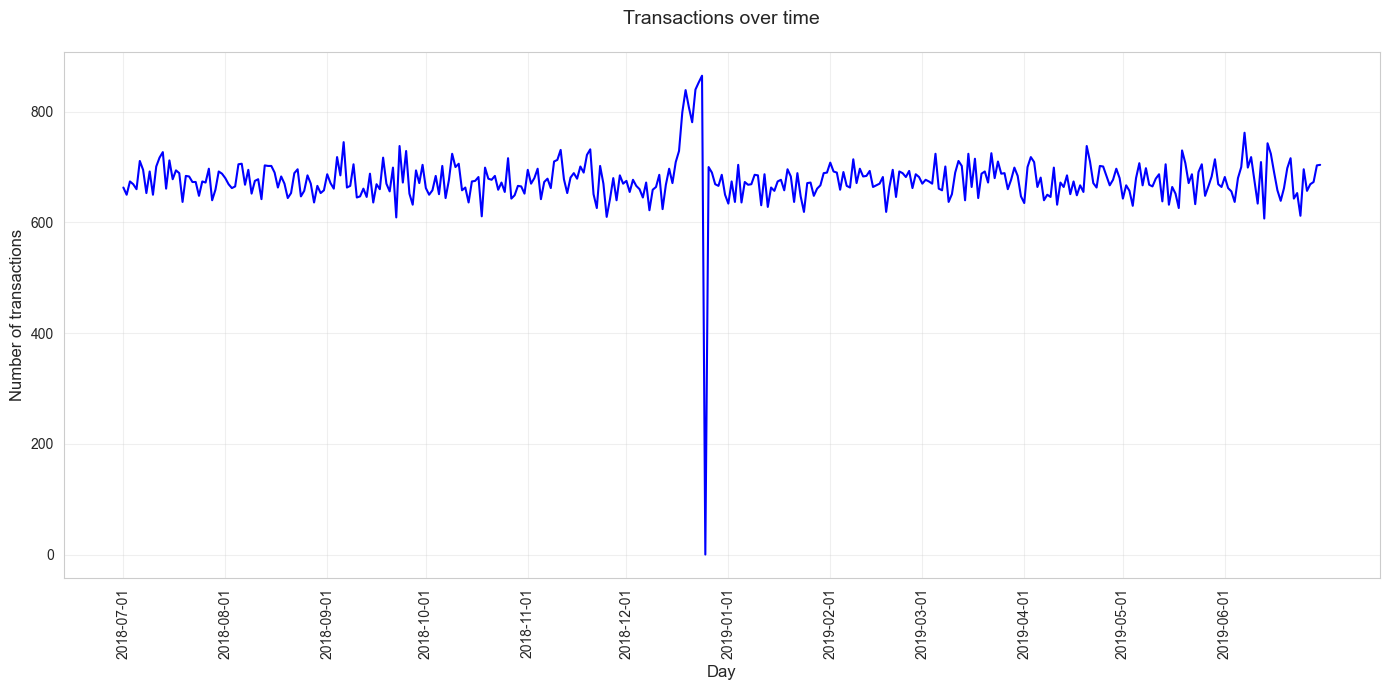

In [21]:
# Plot transactions over time
# =============================================================

plt.figure(figsize=(14, 7))
plt.plot(transactions_by_day_full['DATE'], 
         transactions_by_day_full['N'], 
         color='blue', linewidth=1.5)

plt.title('Transactions over time', fontsize=14, pad=20)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)

# Format x-axis to show monthly ticks with rotation
plt.xticks(pd.date_range(start='2018-07-01', end='2019-06-30', freq='MS'),
           rotation=90)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

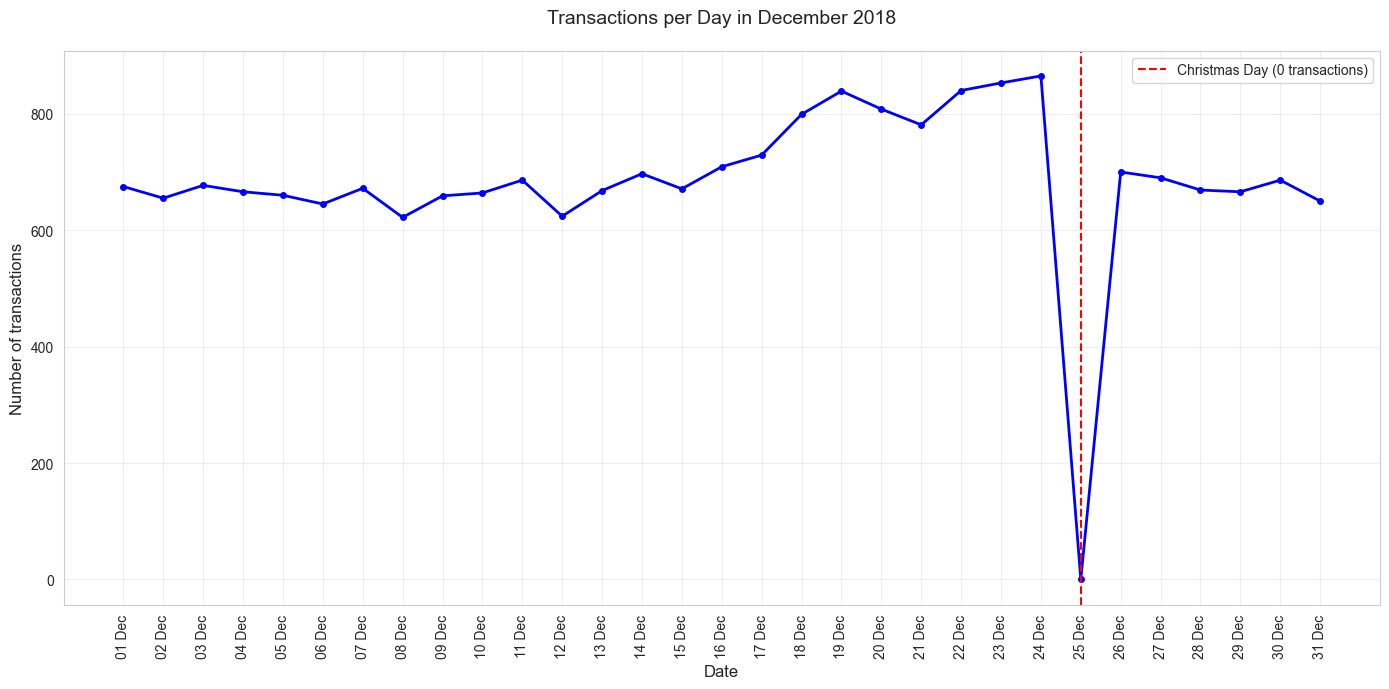

In [22]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Zoom in on December 2018 to see the Christmas period
# =============================================================

# Filter the full daily data to December 2018 only
december_data = transactions_by_day_full[
    (transactions_by_day_full['DATE'] >= '2018-12-01') & 
    (transactions_by_day_full['DATE'] <= '2018-12-31')
].copy()

plt.figure(figsize=(14, 7))
plt.plot(december_data['DATE'], december_data['N'], 
         color='blue', linewidth=2, marker='o', markersize=4)

plt.title('Transactions per Day in December 2018', fontsize=14, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of transactions', fontsize=12)


plt.xticks(december_data['DATE'], 
           december_data['DATE'].dt.strftime('%d %b'), 
           rotation=90)

plt.grid(True, alpha=0.3)
plt.axvline(pd.to_datetime('2018-12-25'), color='red', linestyle='--', 
            label='Christmas Day (0 transactions)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
print("December 2018 daily transactions:")
print(december_data[['DATE', 'N']].to_string(index=False))

December 2018 daily transactions:
      DATE     N
2018-12-01 675.0
2018-12-02 655.0
2018-12-03 677.0
2018-12-04 666.0
2018-12-05 660.0
2018-12-06 645.0
2018-12-07 672.0
2018-12-08 622.0
2018-12-09 659.0
2018-12-10 664.0
2018-12-11 686.0
2018-12-12 624.0
2018-12-13 668.0
2018-12-14 697.0
2018-12-15 671.0
2018-12-16 709.0
2018-12-17 729.0
2018-12-18 799.0
2018-12-19 839.0
2018-12-20 808.0
2018-12-21 781.0
2018-12-22 840.0
2018-12-23 853.0
2018-12-24 865.0
2018-12-25   0.0
2018-12-26 700.0
2018-12-27 690.0
2018-12-28 669.0
2018-12-29 666.0
2018-12-30 686.0
2018-12-31 650.0


### Extract PACK_SIZE (the digits in grams) from PROD_NAME


In [24]:
tran_data_copied["PACK_SIZE"] = tran_data_copied["PROD_NAME"].str.extract(r"(\d+)").astype(int)

print("Pack sizes and their frequencies:")
print(
    tran_data_copied['PACK_SIZE']
    .value_counts()
    .sort_index()
    .reset_index(name='N')
)

Pack sizes and their frequencies:
    PACK_SIZE      N
0          70   1507
1          90   3008
2         110  22387
3         125   1454
4         134  25102
5         135   3257
6         150  40203
7         160   2970
8         165  15297
9         170  19983
10        175  66390
11        180   1468
12        190   2995
13        200   4473
14        210   6272
15        220   1564
16        250   3169
17        270   6285
18        330  12540
19        380   6416


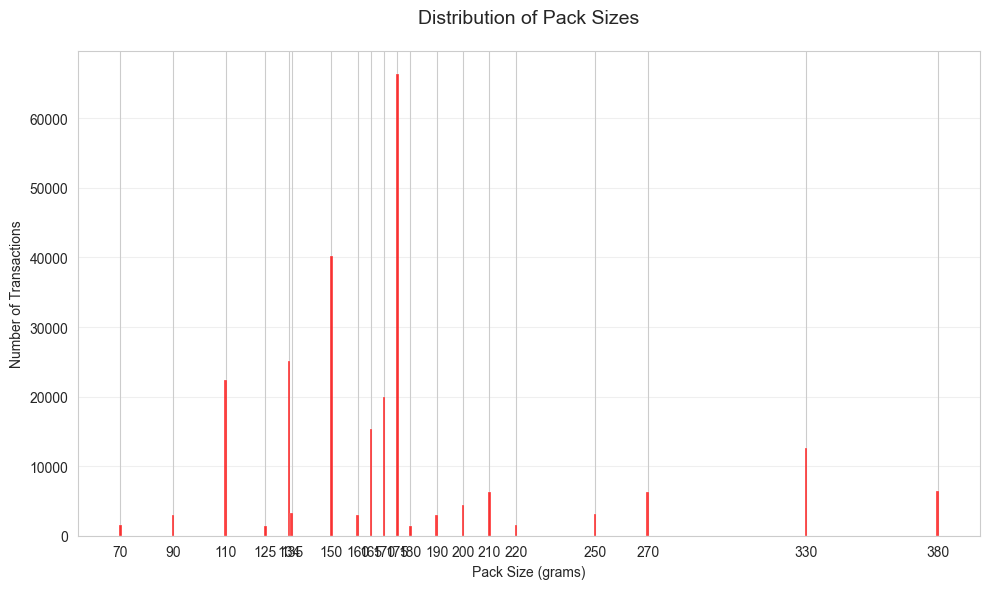

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(data=tran_data_copied, x='PACK_SIZE', bins=20, discrete=True, color='red')

plt.title('Distribution of Pack Sizes', fontsize=14, pad=20)
plt.xlabel('Pack Size (grams)')
plt.ylabel('Number of Transactions')
plt.xticks(sorted(tran_data_copied['PACK_SIZE'].unique()))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Extract BRAND as the FIRST WORD of PROD_NAME

In [27]:
tran_data_copied["BRAND"] = tran_data_copied["PROD_NAME"].str.split().str[0].str.upper()

print("\nBrand frequencies before cleaning:")
print(tran_data_copied['BRAND'].value_counts().sort_index())


Brand frequencies before cleaning:
BRAND
BURGER         1564
CCS            4551
CHEETOS        2927
CHEEZELS       4603
COBS           9693
DORITO         3183
DORITOS       22041
FRENCH         1418
GRAIN          6272
GRNWVES        1468
INFUZIONS     11057
INFZNS         3144
KETTLE        41288
NATURAL        6050
NCC            1419
PRINGLES      25102
RED            4427
RRD           11894
SMITH          2963
SMITHS        27390
SNBTS          1576
SUNBITES       1432
THINS         14075
TOSTITOS       9471
TWISTIES       9454
TYRRELLS       6442
WOOLWORTHS     1516
WW            10320
Name: count, dtype: int64


In [28]:
tran_data_copied.loc[tran_data_copied['BRAND'] == 'RED', 'BRAND'] = 'RRD'
tran_data_copied.loc[tran_data_copied['BRAND'] == "SNBTS", 'BRAND'] = 'SUNBITES'
tran_data_copied.loc[tran_data_copied['BRAND'] == 'INFZNS', 'BRAND'] = 'INFUZIONS'
tran_data_copied.loc[tran_data_copied['BRAND'] == "WW", 'BRAND'] = 'WOOLWORTHS'
tran_data_copied.loc[tran_data_copied['BRAND'] == 'SMITH', 'BRAND'] = 'SMITHS'
tran_data_copied.loc[tran_data_copied['BRAND'] == "NCC", 'BRAND'] = 'NATURAL'
tran_data_copied.loc[tran_data_copied['BRAND'] == 'DORITO', 'BRAND'] = 'DORITOS'
tran_data_copied.loc[tran_data_copied['BRAND'] == "GRAIN", 'BRAND'] = 'GRNWVES'


In [31]:
print("\nBrand frequencies AFTER cleaning:")
brand_summary = tran_data_copied['BRAND'].value_counts().reset_index()
brand_summary.columns = ['BRAND', 'N']
print(brand_summary.sort_values('BRAND'))




Brand frequencies AFTER cleaning:
         BRAND      N
18      BURGER   1564
15         CCS   4551
17     CHEETOS   2927
14    CHEEZELS   4603
8         COBS   9693
2      DORITOS  25224
19      FRENCH   1418
11     GRNWVES   7740
5    INFUZIONS  14201
0       KETTLE  41288
12     NATURAL   7469
3     PRINGLES  25102
4          RRD  16321
1       SMITHS  30353
16    SUNBITES   3008
6        THINS  14075
9     TOSTITOS   9471
10    TWISTIES   9454
13    TYRRELLS   6442
7   WOOLWORTHS  11836


In [32]:
print("\nTop brands by number of transactions:")
print(brand_summary.sort_values('N', ascending=False))


Top brands by number of transactions:
         BRAND      N
0       KETTLE  41288
1       SMITHS  30353
2      DORITOS  25224
3     PRINGLES  25102
4          RRD  16321
5    INFUZIONS  14201
6        THINS  14075
7   WOOLWORTHS  11836
8         COBS   9693
9     TOSTITOS   9471
10    TWISTIES   9454
11     GRNWVES   7740
12     NATURAL   7469
13    TYRRELLS   6442
14    CHEEZELS   4603
15         CCS   4551
16    SUNBITES   3008
17     CHEETOS   2927
18      BURGER   1564
19      FRENCH   1418


In [34]:
data = pd.merge(tran_data_copied, purch_data_copied, how="left")

In [35]:
print(f"Original transaction rows : {len(tran_data_copied)}")
print(f"Rows after merging with customer data: {len(data)}")

Original transaction rows : 246740
Rows after merging with customer data: 246740


In [36]:
print("\n=== Missing values after merge ===")
missing = data.isnull().sum()
print(missing[missing > 0])


=== Missing values after merge ===
Series([], dtype: int64)


In [ ]:
# data.to_csv("QVI_data.csv", index=False)

## Data analysis on customer segments 

In [39]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

### Total sales revenue by LIFESTAGE and PREMIUM_CUSTOMER

In [38]:
sales_summary = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES']
    .sum()
    .reset_index(name='TOTAL_SALES')
    .sort_values('TOTAL_SALES', ascending=False)
)

print("Total Sales by LIFESTAGE and PREMIUM_CUSTOMER:")
print(sales_summary)

Total Sales by LIFESTAGE and PREMIUM_CUSTOMER:
                 LIFESTAGE PREMIUM_CUSTOMER  TOTAL_SALES
6           OLDER FAMILIES           Budget    156863.75
19   YOUNG SINGLES/COUPLES       Mainstream    147582.20
13                RETIREES       Mainstream    145168.95
15          YOUNG FAMILIES           Budget    129717.95
9    OLDER SINGLES/COUPLES           Budget    127833.60
10   OLDER SINGLES/COUPLES       Mainstream    124648.50
11   OLDER SINGLES/COUPLES          Premium    123537.55
12                RETIREES           Budget    105916.30
7           OLDER FAMILIES       Mainstream     96413.55
14                RETIREES          Premium     91296.65
16          YOUNG FAMILIES       Mainstream     86338.25
1   MIDAGE SINGLES/COUPLES       Mainstream     84734.25
17          YOUNG FAMILIES          Premium     78571.70
8           OLDER FAMILIES          Premium     75242.60
18   YOUNG SINGLES/COUPLES           Budget     57122.10
2   MIDAGE SINGLES/COUPLES          Premi

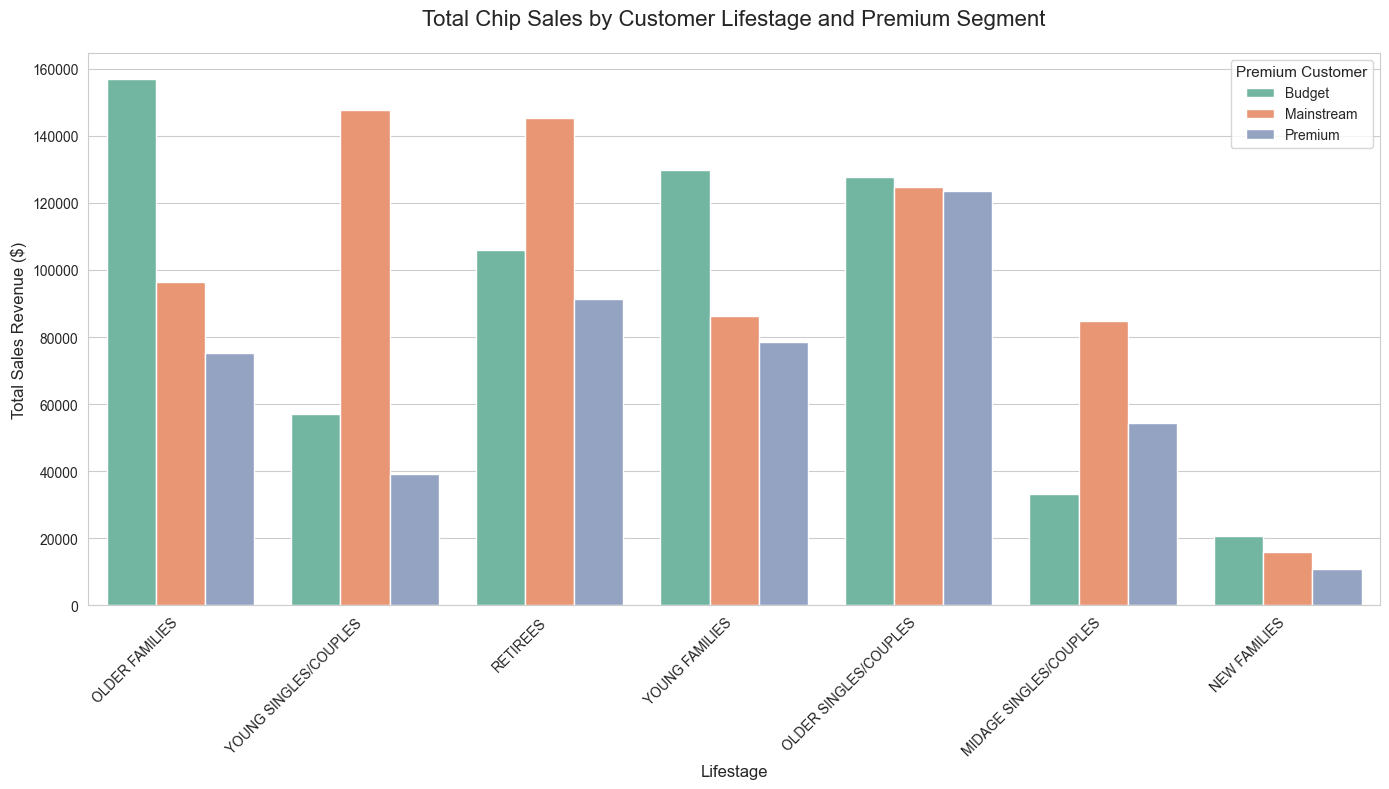

In [40]:
plt.figure(figsize=(14, 8))

sns.barplot(
    data=sales_summary,
    x='LIFESTAGE',
    y='TOTAL_SALES',
    hue='PREMIUM_CUSTOMER',
    palette='Set2'
)

plt.title('Total Chip Sales by Customer Lifestage and Premium Segment', fontsize=16, pad=20)
plt.xlabel('Lifestage', fontsize=12)
plt.ylabel('Total Sales Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer', title_fontsize=11)
plt.tight_layout()
plt.show()

### Number of Customers by LIFESTAGE and PREMIUM_CUSTOMER

In [41]:
customer_summary = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['LYLTY_CARD_NBR']
    .nunique()
    .reset_index(name='NUM_CUSTOMERS')
    .sort_values('NUM_CUSTOMERS', ascending=False)
)

print("Number of Customers by Lifestage and Premium Segment:")
print(customer_summary)

Number of Customers by Lifestage and Premium Segment:
                 LIFESTAGE PREMIUM_CUSTOMER  NUM_CUSTOMERS
19   YOUNG SINGLES/COUPLES       Mainstream           7917
13                RETIREES       Mainstream           6358
10   OLDER SINGLES/COUPLES       Mainstream           4858
9    OLDER SINGLES/COUPLES           Budget           4849
11   OLDER SINGLES/COUPLES          Premium           4682
6           OLDER FAMILIES           Budget           4611
12                RETIREES           Budget           4385
15          YOUNG FAMILIES           Budget           3953
14                RETIREES          Premium           3812
18   YOUNG SINGLES/COUPLES           Budget           3647
1   MIDAGE SINGLES/COUPLES       Mainstream           3298
7           OLDER FAMILIES       Mainstream           2788
16          YOUNG FAMILIES       Mainstream           2685
20   YOUNG SINGLES/COUPLES          Premium           2480
17          YOUNG FAMILIES          Premium           2398
2 

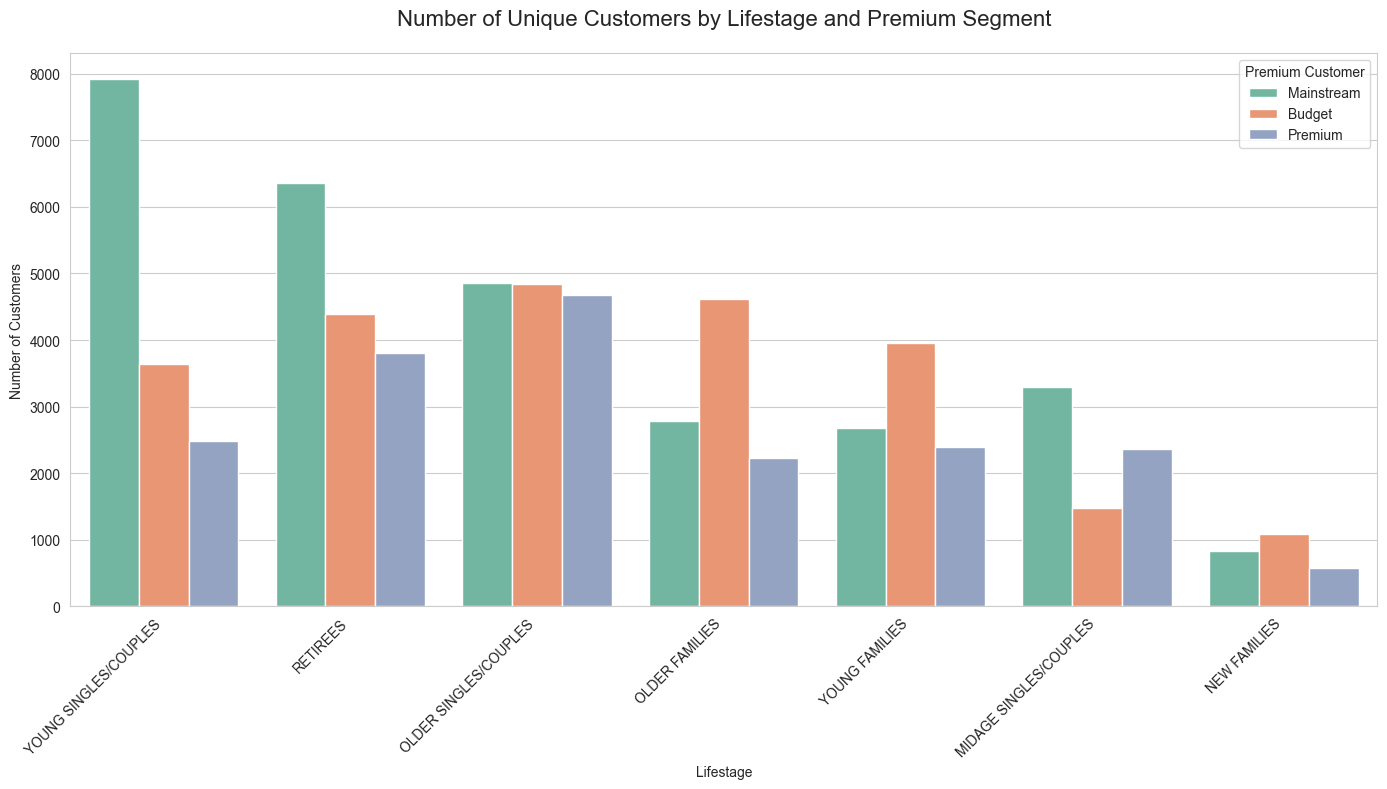

In [43]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=customer_summary,
    x='LIFESTAGE',
    y='NUM_CUSTOMERS',
    hue='PREMIUM_CUSTOMER',
    palette='Set2'
)

plt.title('Number of Unique Customers by Lifestage and Premium Segment', fontsize=16, pad=20)
plt.xlabel('Lifestage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

#### Average units (PROD_QTY) per customer by LIFESTAGE and PREMIUM_CUSTOMER

In [44]:
avg_units = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        TOTAL_UNITS=('PROD_QTY', 'sum'),
        NUM_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique')
    )
    .reset_index()
)

avg_units['AVG_UNITS_PER_CUSTOMER'] = avg_units['TOTAL_UNITS'] / avg_units['NUM_CUSTOMERS']

# Sort for nicer display
avg_units = avg_units.sort_values('AVG_UNITS_PER_CUSTOMER', ascending=False)

print("\nAverage Units per Customer by Lifestage and Premium Segment:")
print(avg_units[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_UNITS_PER_CUSTOMER']])


Average Units per Customer by Lifestage and Premium Segment:
                 LIFESTAGE PREMIUM_CUSTOMER  AVG_UNITS_PER_CUSTOMER
7           OLDER FAMILIES       Mainstream                9.255380
6           OLDER FAMILIES           Budget                9.076773
8           OLDER FAMILIES          Premium                9.071717
15          YOUNG FAMILIES           Budget                8.722995
17          YOUNG FAMILIES          Premium                8.716013
16          YOUNG FAMILIES       Mainstream                8.638361
9    OLDER SINGLES/COUPLES           Budget                6.781398
11   OLDER SINGLES/COUPLES          Premium                6.769543
10   OLDER SINGLES/COUPLES       Mainstream                6.712021
1   MIDAGE SINGLES/COUPLES       Mainstream                6.432080
12                RETIREES           Budget                6.141847
14                RETIREES          Premium                6.103358
2   MIDAGE SINGLES/COUPLES          Premium           

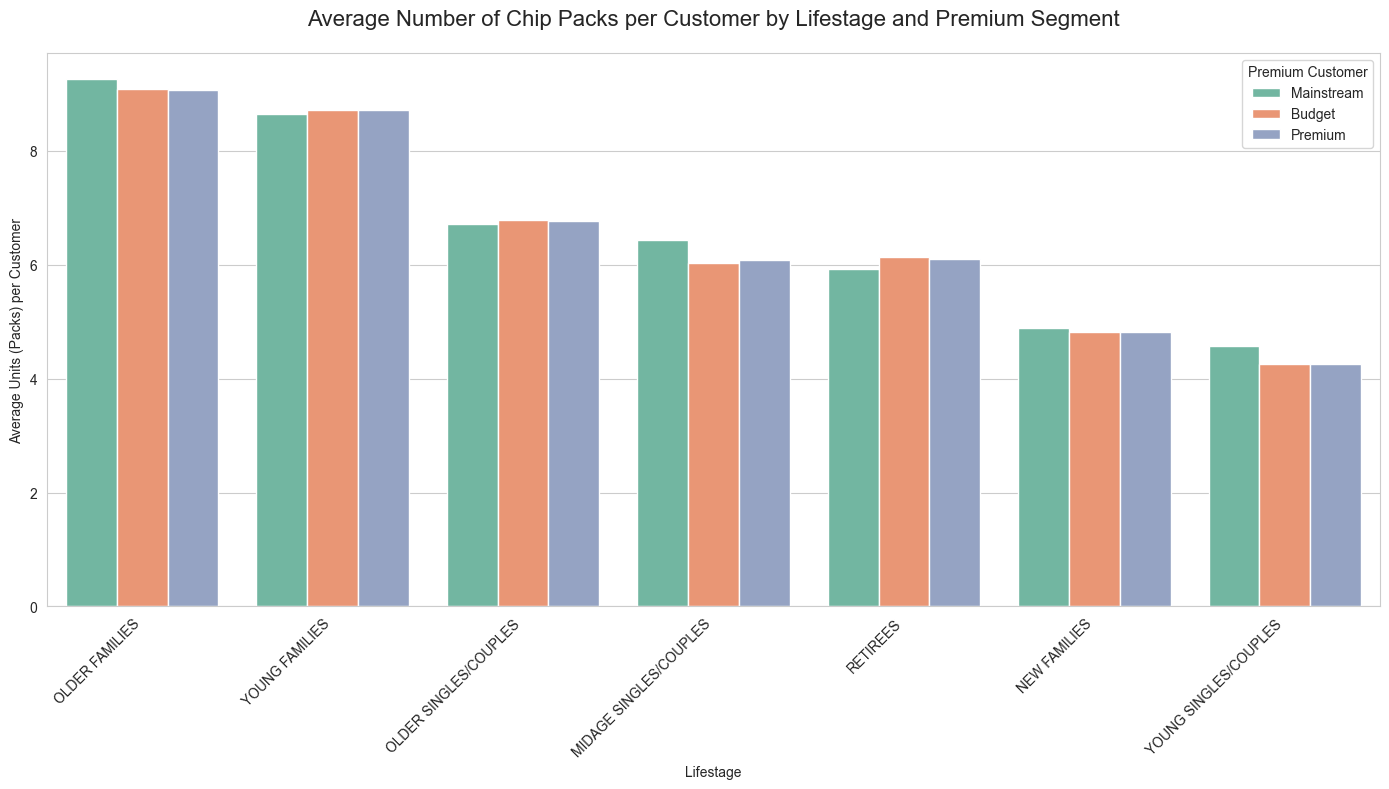

In [45]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=avg_units,
    x='LIFESTAGE',
    y='AVG_UNITS_PER_CUSTOMER',
    hue='PREMIUM_CUSTOMER',
    palette='Set2'
)

plt.title('Average Number of Chip Packs per Customer by Lifestage and Premium Segment', 
          fontsize=16, pad=20)
plt.xlabel('Lifestage')
plt.ylabel('Average Units (Packs) per Customer')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

plt.show()

#### Average price per unit (packet) by LIFESTAGE and PREMIUM_CUSTOMER

In [46]:
price_summary = (
    data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        TOTAL_SALES=('TOT_SALES', 'sum'),
        TOTAL_UNITS=('PROD_QTY', 'sum')
    )
    .reset_index()
)

price_summary['AVG_PRICE_PER_UNIT'] = price_summary['TOTAL_SALES'] / price_summary['TOTAL_UNITS']

# Sort for better display
price_summary = price_summary.sort_values('AVG_PRICE_PER_UNIT', ascending=False)

print("Average Price per Unit by Lifestage and Premium Segment:")
print(price_summary[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'AVG_PRICE_PER_UNIT']].round(3))

Average Price per Unit by Lifestage and Premium Segment:
                 LIFESTAGE PREMIUM_CUSTOMER  AVG_PRICE_PER_UNIT
19   YOUNG SINGLES/COUPLES       Mainstream               4.074
1   MIDAGE SINGLES/COUPLES       Mainstream               3.994
4             NEW FAMILIES       Mainstream               3.936
12                RETIREES           Budget               3.933
3             NEW FAMILIES           Budget               3.932
14                RETIREES          Premium               3.924
11   OLDER SINGLES/COUPLES          Premium               3.898
9    OLDER SINGLES/COUPLES           Budget               3.888
5             NEW FAMILIES          Premium               3.886
13                RETIREES       Mainstream               3.853
10   OLDER SINGLES/COUPLES       Mainstream               3.823
2   MIDAGE SINGLES/COUPLES          Premium               3.781
15          YOUNG FAMILIES           Budget               3.762
17          YOUNG FAMILIES          Premium    

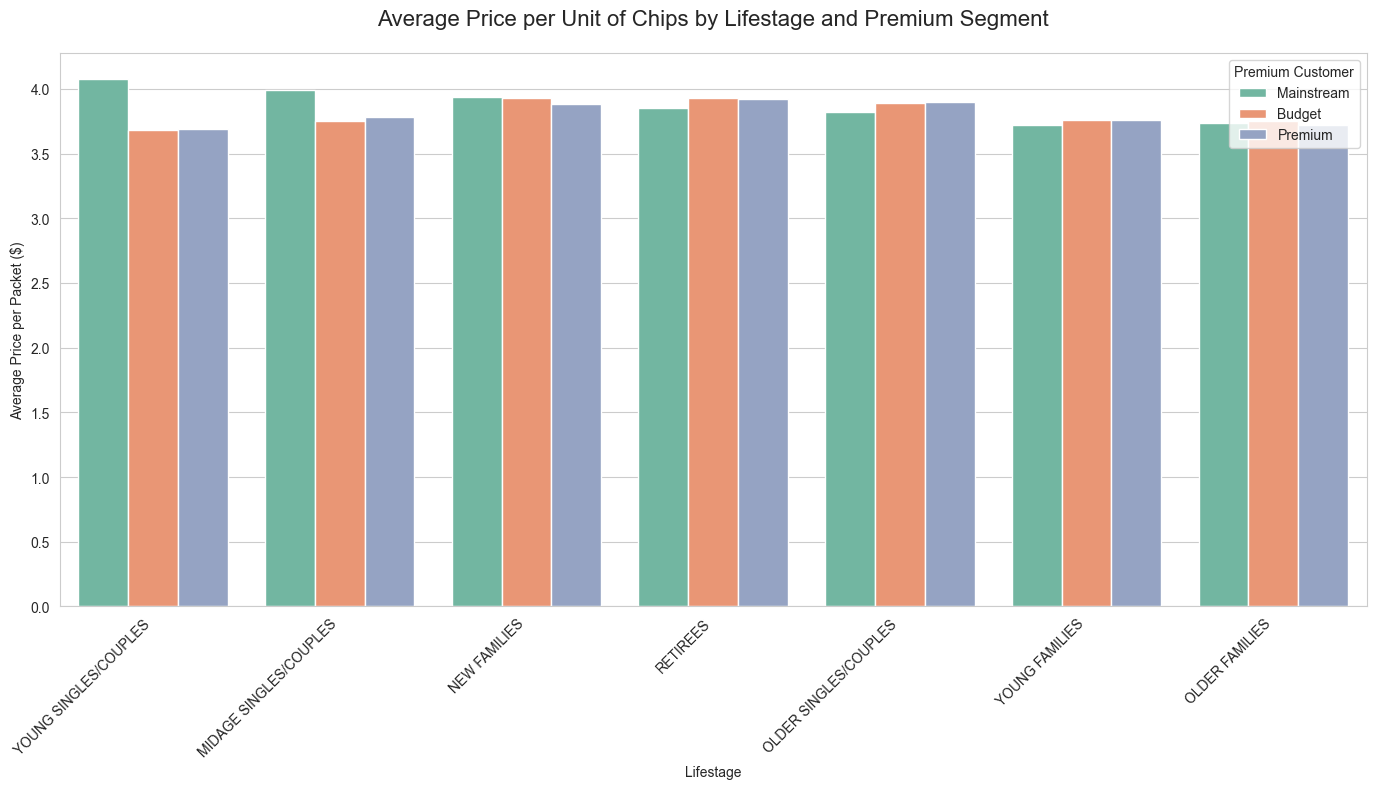

In [47]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=price_summary,
    x='LIFESTAGE',
    y='AVG_PRICE_PER_UNIT',
    hue='PREMIUM_CUSTOMER',
    palette='Set2'
)

plt.title('Average Price per Unit of Chips by Lifestage and Premium Segment', fontsize=16, pad=20)
plt.xlabel('Lifestage')
plt.ylabel('Average Price per Packet ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Premium Customer')
plt.tight_layout()
plt.show()

### T-test: Mainstream vs (Budget + Premium) for Midage + Young Singles/Couples


In [48]:
target_groups = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

test_data = data[
    data['LIFESTAGE'].isin(target_groups)
].copy()

# Create a new column to group: Mainstream vs Others (Budget + Premium)
test_data['GROUP'] = test_data['PREMIUM_CUSTOMER'].apply(
    lambda x: 'Mainstream' if x == 'Mainstream' else 'Budget_Premium'
)

# Calculate unit price for each transaction
test_data['UNIT_PRICE'] = test_data['TOT_SALES'] / test_data['PROD_QTY']

# Separate the two groups
mainstream_price = test_data[test_data['GROUP'] == 'Mainstream']['UNIT_PRICE']
other_price = test_data[test_data['GROUP'] == 'Budget_Premium']['UNIT_PRICE']

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(mainstream_price, other_price, equal_var=False)  # Welch's t-test

print("\n=== T-Test Results ===")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

if p_value < 0.05:
    print("→ The difference is **statistically significant** (p < 0.05)")
    significance = "ARE"
else:
    print("→ The difference is **NOT statistically significant** (p >= 0.05)")
    significance = "ARE NOT"

print(f"\nConclusion: The unit price for Mainstream young and mid-age singles/couples "
      f"{significance} significantly higher than that of Budget or Premium counterparts.")


=== T-Test Results ===
T-statistic : 37.6244
P-value     : 0.000000
→ The difference is **statistically significant** (p < 0.05)

Conclusion: The unit price for Mainstream young and mid-age singles/couples ARE significantly higher than that of Budget or Premium counterparts.


### Deep dive into Mainstream - Young Singles/Couples


In [ ]:
#    Brand preference compared to the rest of the population

target = (data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream')

# Total transactions per brand for target segment and overall
brand_target = (
    data[target]
    .groupby('BRAND')['TOT_SALES']
    .sum()
    .reset_index(name='TARGET_SALES')
)

brand_all = (
    data
    .groupby('BRAND')['TOT_SALES']
    .sum()
    .reset_index(name='ALL_SALES')
)

brand_preference = brand_target.merge(brand_all, on='BRAND')
brand_preference['TARGET_SHARE'] = brand_preference['TARGET_SALES'] / brand_preference['ALL_SALES']

# Overall share of target segment in total sales (for comparison)
overall_target_share = data[target]['TOT_SALES'].sum() / data['TOT_SALES'].sum()

brand_preference['INDEX'] = brand_preference['TARGET_SHARE'] / overall_target_share

# Sort by preference index (higher = more preferred by target segment)
brand_preference = brand_preference.sort_values('INDEX', ascending=False)

print("Brand Preference for Mainstream Young Singles/Couples (Index > 1 = preferred more than average):")
print(brand_preference[['BRAND', 'TARGET_SHARE', 'INDEX']].round(3))

Brand Preference for Mainstream Young Singles/Couples (Index > 1 = preferred more than average):
         BRAND  TARGET_SHARE  INDEX
18    TYRRELLS         0.093  1.137
17    TWISTIES         0.092  1.131
5      DORITOS         0.092  1.131
9       KETTLE         0.091  1.110
16    TOSTITOS         0.091  1.110
11    PRINGLES         0.090  1.102
8    INFUZIONS         0.088  1.080
4         COBS         0.087  1.065
3     CHEEZELS         0.083  1.014
7      GRNWVES         0.081  0.996
15       THINS         0.081  0.994
13      SMITHS         0.069  0.841
6       FRENCH         0.054  0.662
2      CHEETOS         0.053  0.651
12         RRD         0.051  0.630
10     NATURAL         0.050  0.616
1          CCS         0.047  0.575
14    SUNBITES         0.040  0.494
19  WOOLWORTHS         0.039  0.478
0       BURGER         0.036  0.437


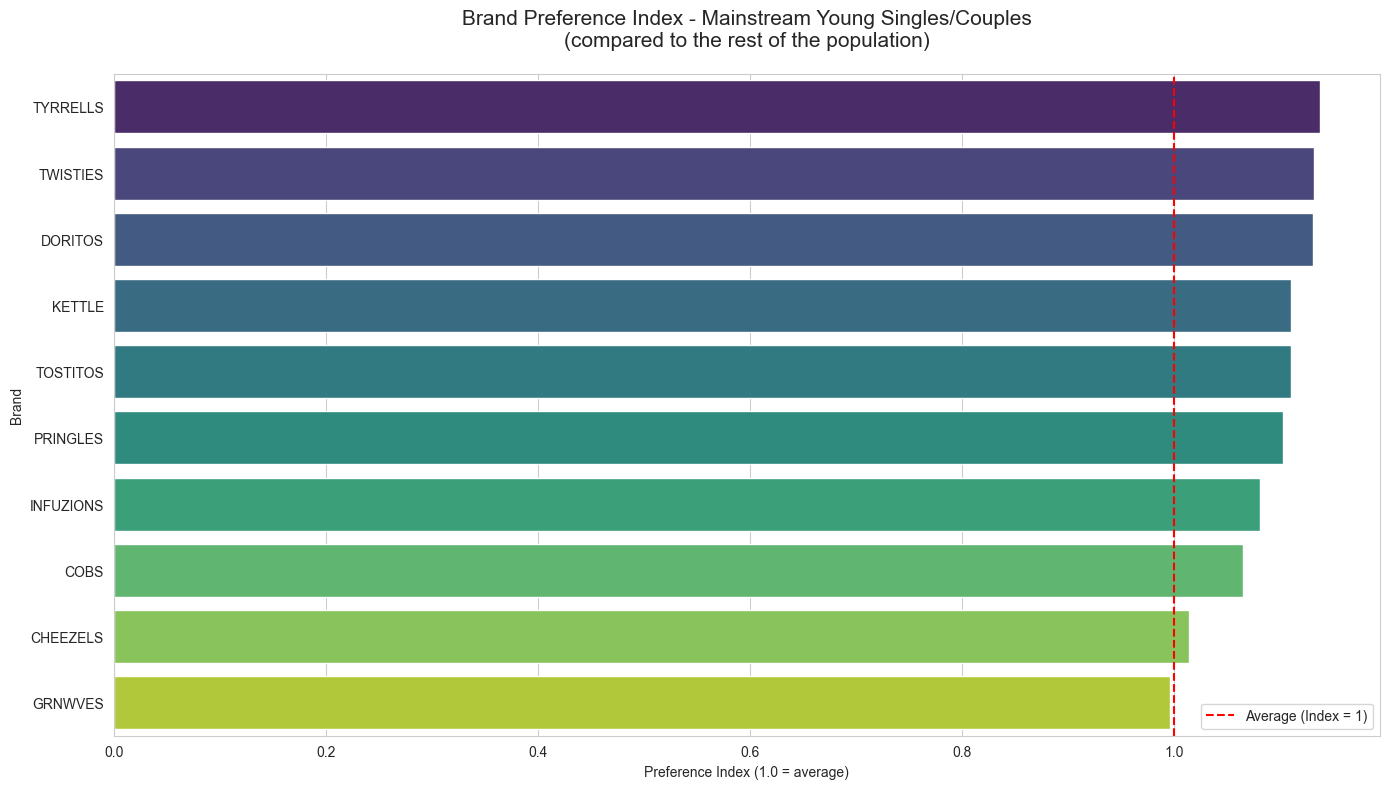

In [54]:
top_brands = brand_preference.head(10)

plt.figure(figsize=(14, 8))
sns.barplot(data=top_brands, x='INDEX', y='BRAND', palette='viridis', hue ='BRAND')
plt.axvline(1, color='red', linestyle='--', label='Average (Index = 1)')
plt.title('Brand Preference Index - Mainstream Young Singles/Couples\n'
          '(compared to the rest of the population)', fontsize=15, pad=20)
plt.xlabel('Preference Index (1.0 = average)')
plt.ylabel('Brand')
plt.legend()
plt.tight_layout()
plt.show()

### Preferred pack size for the target segment

In [51]:
pack_target = (
    data[target]
    .groupby('PACK_SIZE')['TOT_SALES']
    .sum()
    .reset_index(name='TARGET_SALES')
)

pack_all = (
    data
    .groupby('PACK_SIZE')['TOT_SALES']
    .sum()
    .reset_index(name='ALL_SALES')
)

pack_preference = pack_target.merge(pack_all, on='PACK_SIZE')
pack_preference['TARGET_SHARE'] = pack_preference['TARGET_SALES'] / pack_preference['ALL_SALES']
pack_preference['INDEX'] = pack_preference['TARGET_SHARE'] / overall_target_share

pack_preference = pack_preference.sort_values('INDEX', ascending=False)

print("\nPack Size Preference for Mainstream Young Singles/Couples:")
print(pack_preference[['PACK_SIZE', 'TARGET_SHARE', 'INDEX']].round(3))


Pack Size Preference for Mainstream Young Singles/Couples:
    PACK_SIZE  TARGET_SHARE  INDEX
17        270         0.096  1.170
19        380         0.095  1.164
18        330         0.093  1.131
4         134         0.090  1.102
2         110         0.090  1.099
14        210         0.088  1.079
5         135         0.086  1.053
16        250         0.086  1.048
9         170         0.081  0.992
6         150         0.079  0.969
10        175         0.078  0.957
8         165         0.073  0.892
12        190         0.051  0.628
11        180         0.047  0.575
7         160         0.041  0.506
1          90         0.040  0.494
3         125         0.040  0.488
13        200         0.039  0.472
0          70         0.039  0.471
15        220         0.036  0.437


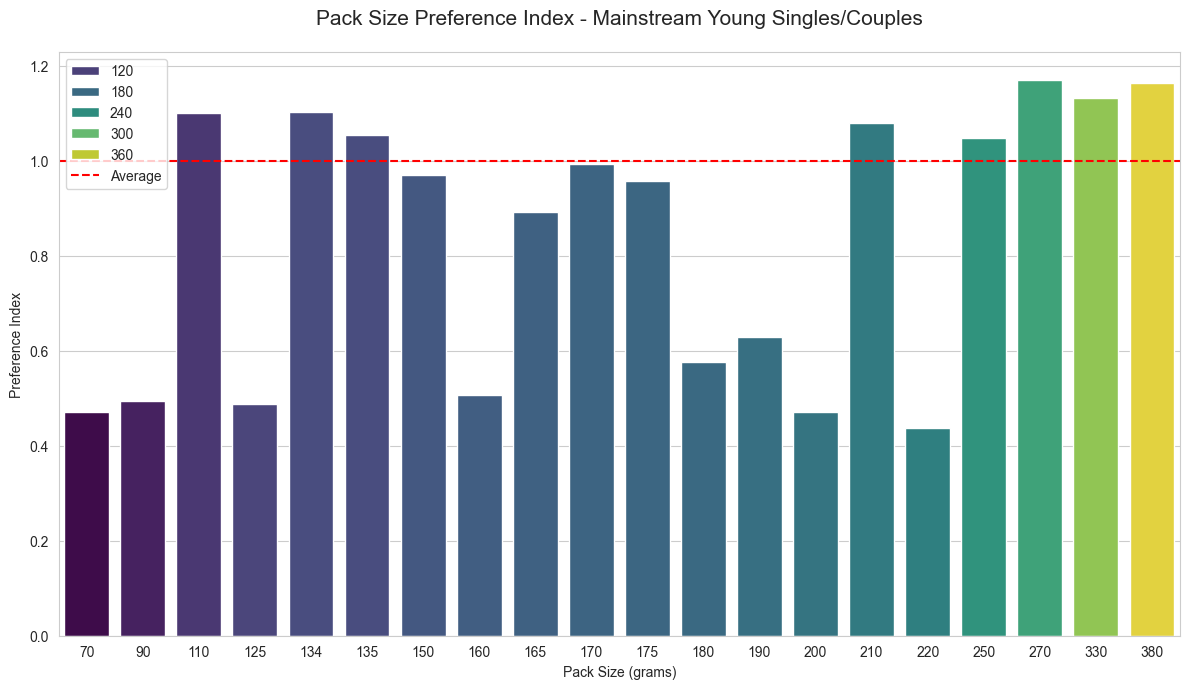

In [59]:
plt.figure(figsize=(12, 7))
sns.barplot(data=pack_preference, x='PACK_SIZE', y='INDEX', palette='viridis',hue='PACK_SIZE')
plt.axhline(1, color='red', linestyle='--', label='Average')
plt.title('Pack Size Preference Index - Mainstream Young Singles/Couples', fontsize=15, pad=20)
plt.xlabel('Pack Size (grams)')
plt.ylabel('Preference Index')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:





target_lifestages = ['YOUNG SINGLES/COUPLES', 'MIDAGE SINGLES/COUPLES']

target_data = data[
    (data['LIFESTAGE'].isin(target_lifestages)) & 
    (data['PREMIUM_CUSTOMER'] == 'Mainstream')
].copy()

# Overall data for comparison
overall_data = data.copy()


segment_pack = (target_data.groupby('PACK_SIZE')['TOT_SALES']
                .sum()
                .reset_index(name='segment_sales'))

segment_total = segment_pack['segment_sales'].sum()
segment_pack['segment_share_%'] = (segment_pack['segment_sales'] / segment_total * 100).round(2)

overall_pack = (overall_data.groupby('PACK_SIZE')['TOT_SALES']
                .sum()
                .reset_index(name='overall_sales'))

overall_total = overall_pack['overall_sales'].sum()
overall_pack['overall_share_%'] = (overall_pack['overall_sales'] / overall_total * 100).round(2)

# Merge and calculate Lift
pack_affinity = segment_pack.merge(overall_pack, on='PACK_SIZE', how='left')
pack_affinity['lift'] = (pack_affinity['segment_share_%'] / 
                        pack_affinity['overall_share_%']).round(2)

# Sort by segment preference
pack_affinity = pack_affinity.sort_values('segment_share_%', ascending=False)

print("=== Pack Size Preference - Mainstream Young & Midage Singles/Couples ===")
print(pack_affinity.head(12)[['PACK_SIZE', 'segment_share_%', 'overall_share_%', 'lift']])



=== Pack Size Preference - Mainstream Young & Midage Singles/Couples ===
    PACK_SIZE  segment_share_%  overall_share_%  lift
10      175.0            26.24            26.87  0.98
6       150.0            15.62            16.04  0.97
4       134.0            10.41             9.83  1.06
2       110.0             9.84             9.01  1.09
18      330.0             8.56             7.57  1.13
9       170.0             7.98             8.12  0.98
8       165.0             5.03             5.61  0.90
19      380.0             4.67             4.25  1.10
17      270.0             3.57             3.07  1.16
14      210.0             2.55             2.38  1.07
5       135.0             1.52             1.44  1.06
16      250.0             1.48             1.44  1.03


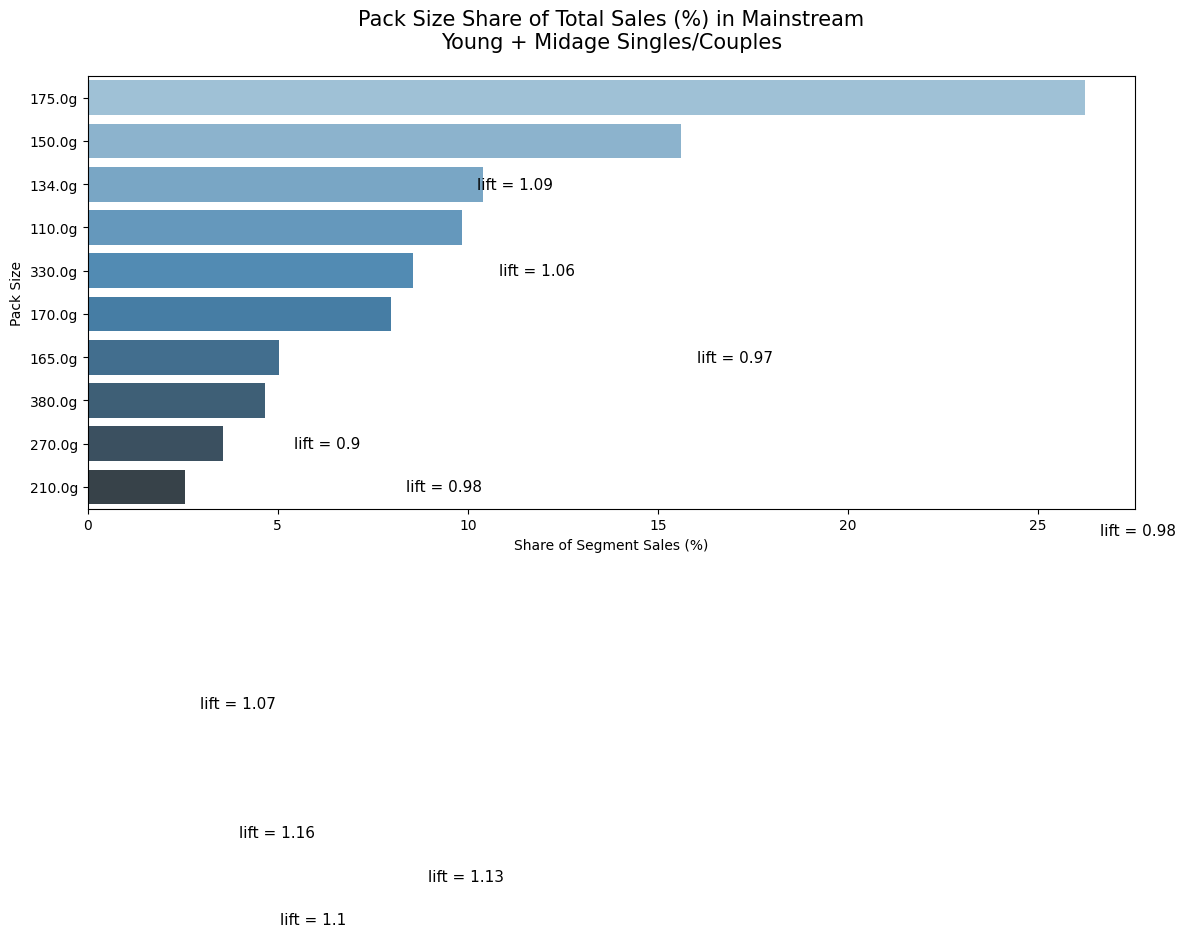

In [ ]:

top_packs = pack_affinity.head(10).copy()

plt.figure(figsize=(12, 20))

sns.barplot(data=top_packs, 
            y=top_packs['PACK_SIZE'].astype(str) + 'g', 
            x='segment_share_%',
            hue=top_packs['PACK_SIZE'].astype(str) + 'g',
            palette='Blues_d',
            legend=False)

plt.title('Pack Size Share of Total Sales (%) in Mainstream\nYoung + Midage Singles/Couples', 
          fontsize=15, pad=20)
plt.xlabel('Share of Segment Sales (%)')
plt.ylabel('Pack Size')

# Add lift values on bars
for i, row in top_packs.iterrows():
    plt.text(row['segment_share_%'] + 0.4, i, 
             f"lift = {row['lift']}", 
             va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

In [ ]:
#data.to_csv("QVI_data.csv", index=False)